In [494]:
%matplotlib inline
import os
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn


In [495]:
#!/bin/bash
#!curl -L -o /content/student-exam-performance-prediction.zip\
#  https://www.kaggle.com/api/v1/datasets/download/mrsimple07/student-exam-performance-prediction

In [496]:
#!unzip -q /content/student-exam-performance-prediction.zip -d /content/student-exam-performance-prediction

In [497]:
path = '/content/student-exam-performance-prediction/'
df = pd.read_csv(path+'student_exam_data.csv')
df

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0
...,...,...,...
495,4.180170,45.494924,0
496,6.252905,95.038815,1
497,1.699612,48.209118,0
498,9.769553,97.014241,1


In [498]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study Hours          500 non-null    float64
 1   Previous Exam Score  500 non-null    float64
 2   Pass/Fail            500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [499]:
df.describe()

,Study Hours,Previous Exam Score,Pass/Fail
count,500.000000,500.000000,500.000000
mean,5.487055,68.917084,0.368000
std,2.688196,17.129607,0.482744
min,1.045554,40.277921,0.000000
25%,3.171517,53.745955,0.000000
50%,5.618474,68.309294,0.000000
75%,7.805124,83.580209,1.000000
max,9.936683,99.983060,1.000000


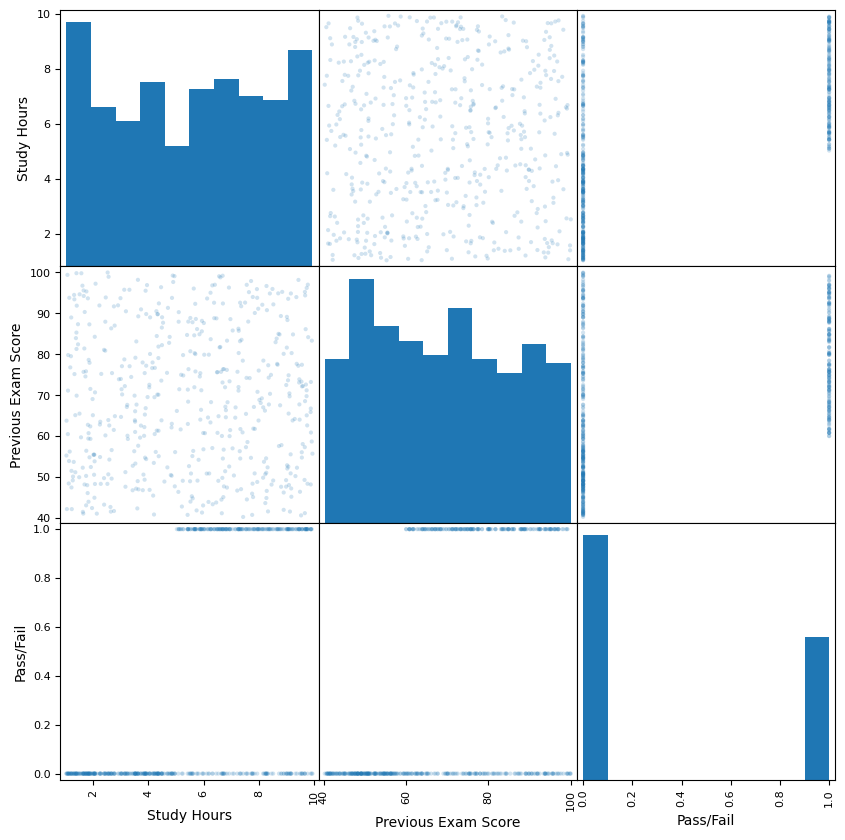

In [500]:
from pandas.plotting import scatter_matrix

scatter_matrix(df, alpha=0.2, figsize=(10, 10), diagonal='hist')
plt.show()

In [501]:
X = df.iloc[:,0:2]
Xc = X - X.min(axis=0)
Xs = Xc.max(axis=0)
Xc = Xc/Xs
Xc

Y = df.iloc[:,2]
Y

,Pass/Fail
0,0
1,1
2,0
3,1
4,0
...,...
495,0
496,1
497,0
498,1


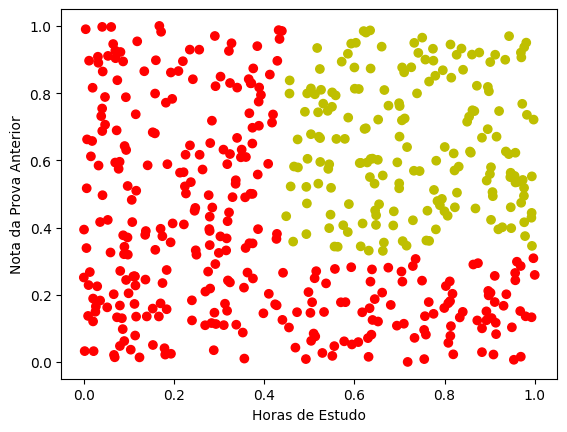

In [502]:
colors = np.array(['r','y','b'])
plt.scatter(Xc.iloc[:, 0], Xc.iloc[:, 1], c=colors[Y])
plt.xlabel('Horas de Estudo')
plt.ylabel('Nota da Prova Anterior')
plt.show()

In [503]:
X_tensor = torch.FloatTensor(Xc.values)
Y_tensor = torch.LongTensor(Y.values)

In [504]:
train_x = X_tensor[:100]
train_y = Y_tensor[:100]
test_x = X_tensor[100:]
test_y = Y_tensor[100:]

In [505]:
model = nn.Linear(2,2)

In [506]:
train_loss = []
val_loss = []
train_acc = []
val_acc = []
model_history = [] # To store weights and bias

lr = 0.5
n_epoch = 1000

optimizer = torch.optim.SGD(model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()

for i in range(n_epoch):
  # Store current model state for visualization
  model_history.append({
      'weight': model.weight.data.clone(),
      'bias': model.bias.data.clone()
  })

  output = model(train_x)
  loss = loss_fn(output,train_y)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  train_loss.append(loss.item())

  _, predicts_train = torch.max(output, 1)
  acc = (predicts_train == train_y).sum().item()/len(train_y)
  train_acc.append(acc)

  with torch.no_grad():
    output_val = model(test_x)
    loss_val = loss_fn(output_val,test_y)
    val_loss.append(loss_val.item())

    _, predicts_val = torch.max(output_val, 1)
    acc_val = (predicts_val == test_y).sum().item()/len(test_y)
    val_acc.append(acc_val)

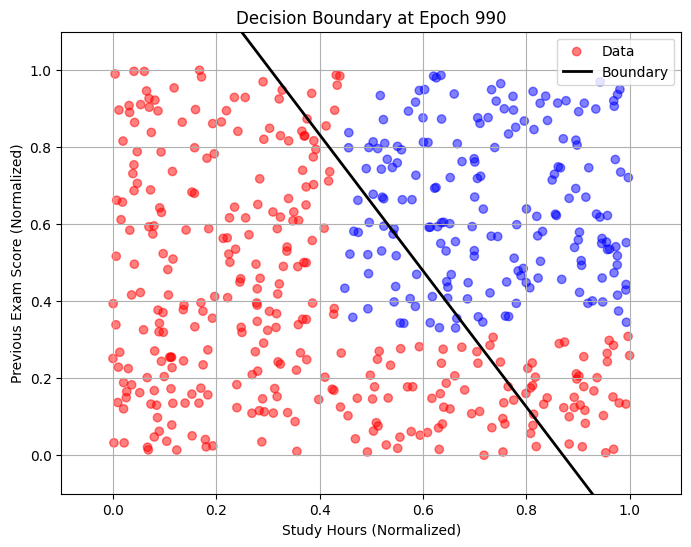

In [511]:
def plot_decision_boundary(epoch_idx):
    if 'model_history' not in globals() or len(model_history) == 0:
        print("Error: 'model_history' is empty. Please ensure the training cell (BvdfJMJr5QFk) has been executed.")
        return

    if epoch_idx >= len(model_history):
        print(f"Epoch index {epoch_idx} out of range. Max index is {len(model_history)-1}")
        return

    params = model_history[epoch_idx]
    weights = params['weight']
    bias = params['bias']

    W = weights[0] - weights[1]
    B = bias[0] - bias[1]

    x_values = np.linspace(0, 1, 100)
    y_values = -(W[0].item() * x_values + B.item()) / W[1].item()

    plt.figure(figsize=(8, 6))
    colors_map = np.array(['r', 'b'])
    plt.scatter(Xc.iloc[:, 0], Xc.iloc[:, 1], c=colors_map[Y], alpha=0.5, label='Data')
    plt.plot(x_values, y_values, color='black', linewidth=2, label='Boundary')

    plt.title(f'Decision Boundary at Epoch {epoch_idx}')
    plt.xlabel('Study Hours (Normalized)')
    plt.ylabel('Previous Exam Score (Normalized)')
    plt.ylim(-0.1, 1.1)
    plt.xlim(-0.1, 1.1)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_decision_boundary(990)

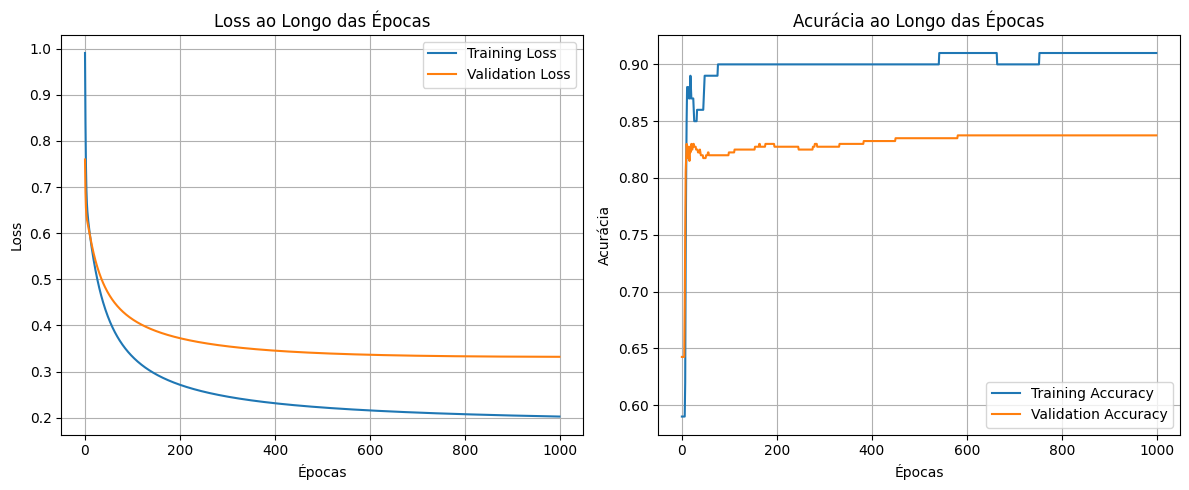

In [508]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()